# Metient-evaluate

##### This tutorial is intended for those who want to run Metient in evaluate mode, where they already know which clones are present at each site.

##### To run this notebook, you'll need metient installed (follow installation instructions on the github README)

### Import libraries and setup paths

In [1]:
import os
import metient as met
import warnings
warnings.filterwarnings('ignore')

### Setup paths
# Path to where our input clone trees and tsvs are located
notebook_dir = '/data1/morrisq/divyak/projects/metient/tutorial'
input_dir = os.path.join(notebook_dir, "inputs")
# Path to save outputs
output_dir = os.path.join(notebook_dir,  "4_outputs")

### An example of the expected tsv file format for NSCLC patient CRUK0010
**The required columns are:**
`anatomical_site_index, anatomical_site_label, cluster_index, cluster_label, present, site_category, num_mutations` (see `../README.md` for description of each column)

In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(input_dir, "CRUK0010_SNVs.tsv"), sep="\t")
df

,anatomical_site_index,anatomical_site_label,cluster_index,cluster_label,present,site_category,num_mutations
0,0,primary_SU_T1,0,SPTAN1;SETD2,0,primary,58
1,1,LN_SU_FLN1,0,SPTAN1;SETD2,0,metastasis,58
2,2,metachronousMet_BR_LN1,0,SPTAN1;SETD2,0,metastasis,58
3,3,metachronousMet_BR_LN2,0,SPTAN1;SETD2,0,metastasis,58
4,4,metachronousMet_BR_LN3,0,SPTAN1;SETD2,0,metastasis,58
...,...,...,...,...,...,...,...
70,0,primary_SU_T1,14,OTUD7B;BVES-AS1,0,primary,5
71,1,LN_SU_FLN1,14,OTUD7B;BVES-AS1,0,metastasis,5
72,2,metachronousMet_BR_LN1,14,OTUD7B;BVES-AS1,0,metastasis,5
73,3,metachronousMet_BR_LN2,14,OTUD7B;BVES-AS1,0,metastasis,5


## Step 1: Run Metient-evaluate on each patient individually
IMPORTANT: For the tutorial, we use default values for `sample_size` and `num_runs`. If you have large trees (>50 nodes), please see our [full guide](https://github.com/morrislab/metient/blob/main/docs/guide.md) on how to set these values.

/data1/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0003_SNVs.tsv
Organotropism frequencies: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1']
Input tree has 16 nodes.


  0%|          | 0/4600 [00:00<?, ?it/s]

  3%|▎         | 122/4600 [00:02<00:58, 77.19it/s]

Number of fixed nodes: 18, number of unknown nodes: 1


100%|█████████▉| 4596/4600 [00:44<00:00, 111.51it/s]

Number of final solutions: 1
CRUK0003_primary_SU_T1


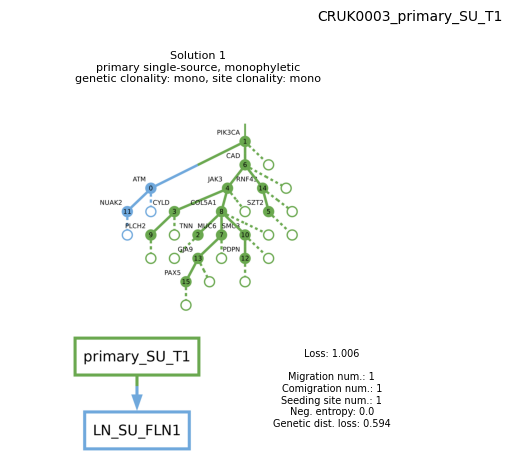

/data1/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0010_SNVs.tsv
Organotropism frequencies: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_LN1', 'metachronousMet_BR_LN2', 'metachronousMet_BR_LN3']
Input tree has 15 nodes.


  3%|▎         | 121/4600 [00:01<00:50, 89.05it/s]

Number of fixed nodes: 14, number of unknown nodes: 2


100%|█████████▉| 4591/4600 [00:32<00:00, 152.02it/s]

Number of final solutions: 1
CRUK0010_primary_SU_T1


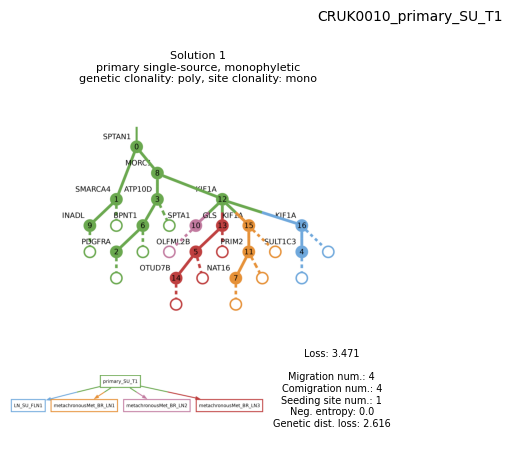

/data1/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0013_SNVs.tsv
Organotropism frequencies: None
Tumor samples: ['LN_SU_LN1', 'LN_SU_LN2', 'primary_SU_T1', 'LN_SU_FLN1', 'LN_SU_FLN2']
Input tree has 7 nodes.


  3%|▎         | 125/4600 [00:00<00:31, 142.12it/s]

Number of fixed nodes: 5, number of unknown nodes: 4


100%|█████████▉| 4583/4600 [00:26<00:00, 178.31it/s]

Number of final solutions: 2
CRUK0013_primary_SU_T1


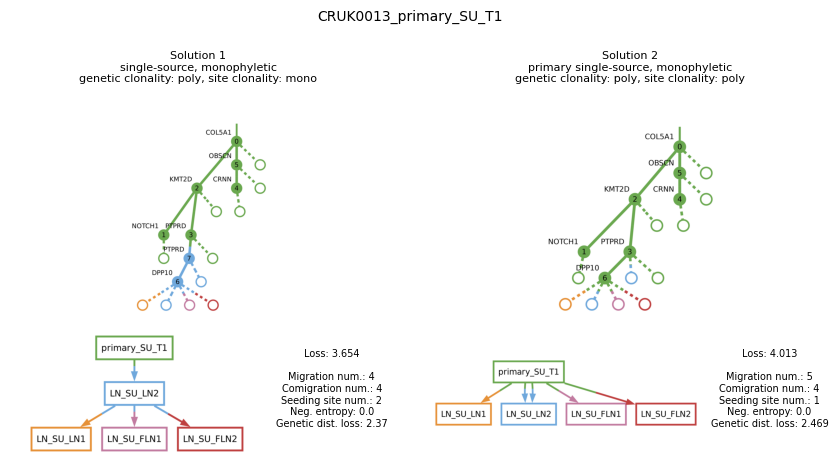

/data1/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0029_SNVs.tsv
Organotropism frequencies: None
Tumor samples: ['LN_SU_LN5', 'LN_SU_LN7', 'primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_T1']
Input tree has 15 nodes.


  2%|▏         | 109/4600 [00:01<01:08, 65.12it/s]

Number of fixed nodes: 14, number of unknown nodes: 5


100%|█████████▉| 4599/4600 [00:48<00:00, 102.69it/s]

Number of final solutions: 2
CRUK0029_primary_SU_T1


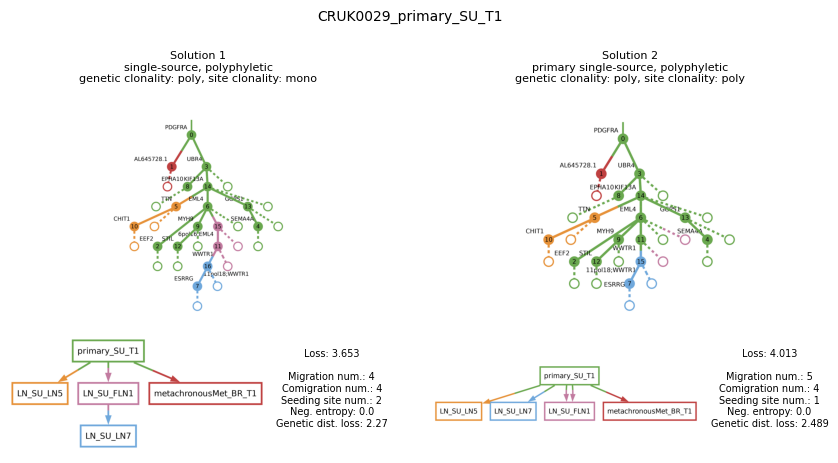

/data1/morrisq/divyak/projects/metient/tutorial/inputs/CRUK0590_SNVs.tsv
Organotropism frequencies: None
Tumor samples: ['primary_SU_T1', 'metachronousMet_BR_T1.FR2', 'metachronousMet_BR_T1.FR1', 'metachronousMet_BR_T3.FR1', 'LN_SU_FLN1']
Input tree has 19 nodes.


  2%|▏         | 112/4600 [00:01<01:14, 60.42it/s]

Number of fixed nodes: 18, number of unknown nodes: 4


100%|█████████▉| 4599/4600 [00:51<00:00, 93.88it/s]

Number of final solutions: 2
CRUK0590_primary_SU_T1


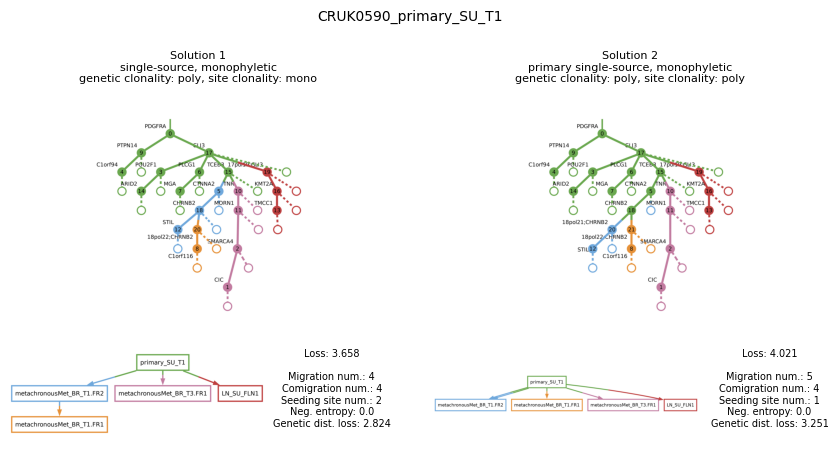

In [3]:
patients = ["CRUK0003", "CRUK0010", "CRUK0013", "CRUK0029", "CRUK0590"]

print_config = met.PrintConfig(visualize=True, verbose=False, k_best_trees=5)
# Use weights which have been calibrated to real data
weights = met.Weights.pancancer_genetic_organotropism_uniform_weighting()
# Optionally, add a small genetic distance penalty to break ties between solutions with equal parsimony metrics
weights.gen_dist = 0.01
for patient in patients:
    clone_tree_fn = os.path.join(input_dir, f"{patient}_tree.txt")
    ref_var_fn = os.path.join(input_dir, f"{patient}_SNVs.tsv")
    met.evaluate_label_clone_tree(clone_tree_fn, ref_var_fn, weights, print_config, output_dir, patient, solve_polytomies=True)


## Step 3: Use the pickle file outputs for downstream analysis

### In addition to the visualizations that Metient provides, we also save pkl.gz files for each Metient run that contain all the results of the run.

In [4]:
import gzip
import pickle

with gzip.open(os.path.join(output_dir, "CRUK0590_primary_SU_T1.pkl.gz") ,"rb") as f:
    pckl = pickle.load(f)
print(pckl.keys())

# Get classifications for clonality and phyleticity, weighted by the probability of each solution
print("Overall genetic clonality:", met.weighted_genetic_clonality(pckl))
print("Overall site clonality:", met.weighted_site_clonality(pckl))
print("Overall phyleticity:", met.weighted_phyleticity(pckl))

print("\nSolution probabilities:", pckl['probabilities'])

# Look at individual solutions:
for idx in range(len(pckl['node_labels'])):
    print("\n===============================")
    print("Solution {idx} probability: {prob:.4f}".format(idx=idx, prob=pckl['probabilities'][idx]))
    # V is the best node labeling
    V = pckl['node_labels'][idx]
    # A is the adjacency matrix that is the input clone tree + inferred witness nodes + polytomy resolved nodes
    parents = pckl['parents'][idx]
    A = met.adjacency_matrix_from_parents(parents)
    # G represents the migration graph
    G = met.migration_graph(V, A)
    print("\nMigration graph:\n", G)

    node_info = pckl['node_info'][idx]

    # Show other information about this inferred migration history
    print("\nSeeding pattern:", met.seeding_pattern(V, A))
    print("Seeding clusters:", met.seeding_clusters(V, A,node_info))
    print("Phyleticity:", met.phyleticity(V, A, node_info))
    print("Site clonality:", met.site_clonality(V, A))
    print("Genetic clonality:", met.genetic_clonality(V, A,node_info))

dict_keys(['node_labels', 'losses', 'node_info', 'parents', 'anatomical_sites', 'loss_info', 'primary_site', 'probabilities', 'soft_labeling', 'genetic_distances', 'observed_proportions'])
Overall genetic clonality: polyclonal
Overall site clonality: monoclonal
Overall phyleticity: monophyletic

Solution probabilities: [0.88079707 0.11920293]

Solution 0 probability: 0.8808

Migration graph:
 tensor([[0., 1., 0., 1., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

Seeding pattern: single-source
Seeding clusters: [17, 10, 18, 5]
Phyleticity: monophyletic
Site clonality: monoclonal
Genetic clonality: polyclonal

Solution 1 probability: 0.1192

Migration graph:
 tensor([[0., 2., 1., 1., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

Seeding pattern: primary single-source
Seeding clusters: [17, 10, 18, 5]
Phyleticity: monophyletic
Si

100%|██████████| 4600/4600 [01:04<00:00, 93.88it/s]